## DS 6050 Final Project

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# get data path
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\shawn\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1


In [3]:
# see list of data files
print(os.listdir(path))

['Meta', 'Meta.csv', 'Test', 'Test.csv', 'Train', 'Train.csv']


In [4]:
# Load in train and test csv
train_df = pd.read_csv(os.path.join(path, "Train.csv"))
test_df = pd.read_csv(os.path.join(path, "Test.csv"))

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print(train_df.head())
print( f"\nSuccessfully loaded metadata for {len(train_df)} images.")

Train rows: 39209 Test rows: 12630
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Successfully loaded metadata for 39209 images.


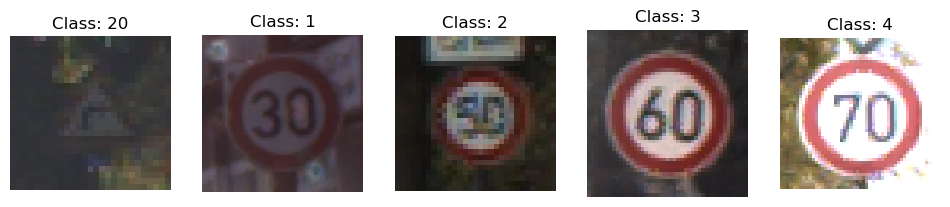

In [5]:
# quickly look at a few images with annotation
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    img_relative_path = train_df.iloc[i * 2000]['Path']
    img_full_path = os.path.join(path, img_relative_path)
    
    img = Image.open(img_full_path)
    plt.imshow(img)
    plt.title(f"Class: {train_df.iloc[i * 2000]['ClassId']}")
    plt.axis('off')
plt.show()

In [6]:
# Build tf.data pipeline
IMG_SIZE = (32, 32)
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
test_ds = make_dataset(test_df, training=False)

In [7]:
# build a model

model = models.Sequential([
    Input(shape=(32, 32, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Quick training run ( will set epochs higher later)
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4298 - loss: 2.0644 - val_accuracy: 0.4861 - val_loss: 1.7882
Epoch 2/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.7583 - loss: 0.7394 - val_accuracy: 0.7435 - val_loss: 0.8898
Epoch 3/3
613/613 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.8984 - loss: 0.3201 - val_accuracy: 0.8402 - val_loss: 0.6011


In [9]:
# Prediction demo
x_batch, y_batch = next(iter(test_ds))
probs = model.predict(x_batch, verbose=0)
preds = tf.argmax(probs, axis=1)

print("Predicted:", preds[:10].numpy())
print("Actual:   ", y_batch[:10].numpy())

Predicted: [16  1 38 33 11 38 18 12 25 35]
Actual:    [16  1 38 33 11 38 18 12 25 35]


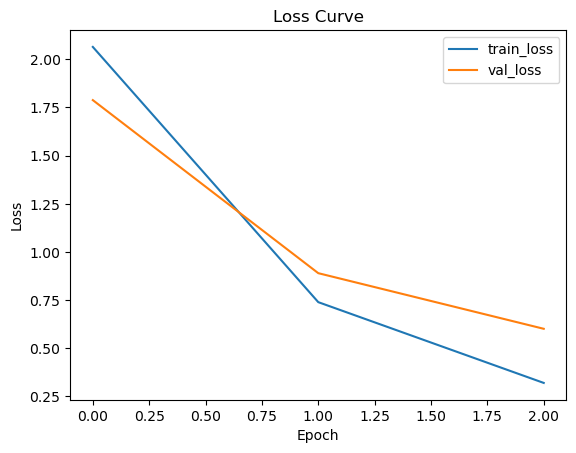

In [10]:
# plotting Loss curve
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

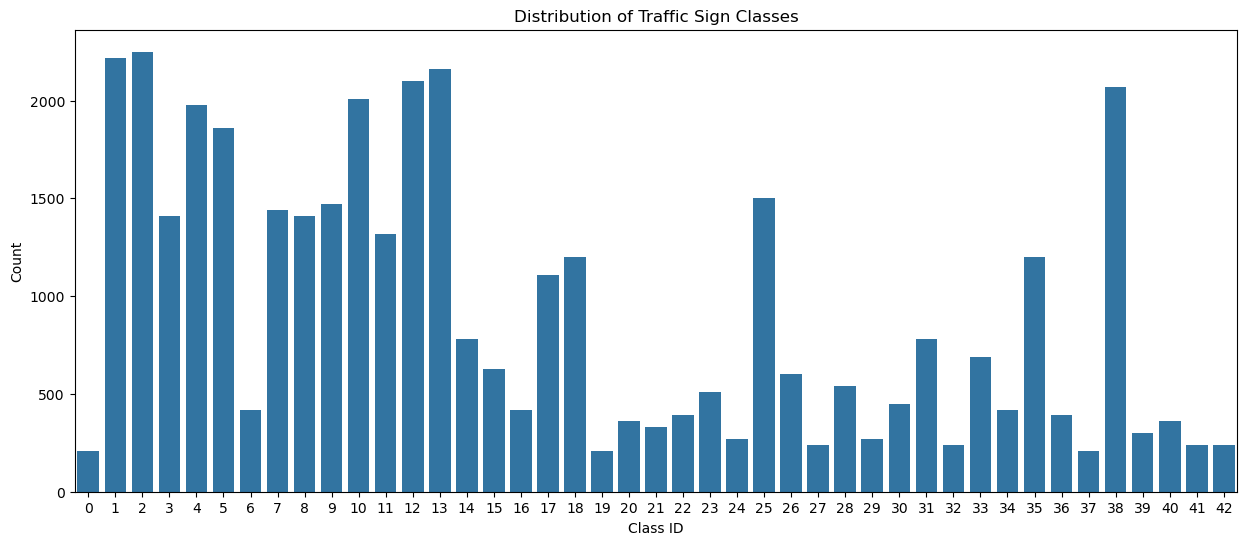

In [11]:
# 1.1 Class Distribution (EDA)
plt.figure(figsize=(15, 6))
sns.countplot(x='ClassId', data=train_df)
plt.title('Distribution of Traffic Sign Classes')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.show()

# 1.2 Updated Dataset Pipeline with Augmentation
def make_augmented_dataset(df, training=True):
    paths = [os.path.join(path, p) for p in df["Path"].values]
    labels = df["ClassId"].values.astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    # Data Augmentation Layer (Rotation ±15°)
    data_augmentation = tf.keras.Sequential([
        layers.RandomRotation(0.04), # 0.04 * 2pi is approx 15 degrees
    ])

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(5000, seed=42)
        # Apply augmentation only to training data
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_aug = make_augmented_dataset(train_df, training=True)

In [ ]:
# 2.1 Baseline: LeNet-5
def build_lenet5():
    model = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(6, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(43, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 2.2 Primary Model: Custom CNN
def build_custom_cnn(use_dropout=True):
    layers_list = [
        Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
    ]
    if use_dropout:
        layers_list.append(layers.Dropout(0.2))
    
    layers_list.append(layers.Dense(43, activation='softmax'))
    
    model = models.Sequential(layers_list)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [13]:
EPOCHS = 10 # Set to 10-15 for stable results

# Experiment 1: Baseline (LeNet-5)
print("\n--- Training Experiment 1: LeNet-5 ---")
lenet_model = build_lenet5()
history_lenet = lenet_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)

# Experiment 2: Primary (Custom CNN + Dropout)
print("\n--- Training Experiment 2: Custom CNN (Primary) ---")
primary_model = build_custom_cnn(use_dropout=True)
history_primary = primary_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)

# Experiment 3: Ablation (Custom CNN No Dropout)
print("\n--- Training Experiment 3: Custom CNN (Ablation) ---")
ablation_model = build_custom_cnn(use_dropout=False)
history_ablation = ablation_model.fit(train_ds_aug, validation_data=test_ds, epochs=EPOCHS)


--- Training Experiment 1: LeNet-5 ---
Epoch 1/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3336 - loss: 2.3178 - val_accuracy: 0.3768 - val_loss: 3.1587
Epoch 2/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.6526 - loss: 1.0878 - val_accuracy: 0.5831 - val_loss: 1.5540
Epoch 3/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.8353 - loss: 0.5210 - val_accuracy: 0.7116 - val_loss: 1.1235
Epoch 4/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.9083 - loss: 0.2985 - val_accuracy: 0.8055 - val_loss: 0.8222
Epoch 5/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9422 - loss: 0.1934 - val_accuracy: 0.8447 - val_loss: 0.7296
Epoch 6/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9570 - loss: 0.1506 - val_accuracy: 0.8689 - val_loss: 0.5970
Epoch 7/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.9645 - loss: 0.1215 - val_accuracy: 0.8690 - val_loss: 0.6533
Epoch 8/10
613/613 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/s


Evaluation for Custom CNN (Primary):
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        60
           1       0.92      0.98      0.95       720
           2       0.96      0.93      0.95       750
           3       0.89      0.84      0.87       450
           4       1.00      0.87      0.93       660
           5       0.79      0.91      0.85       630
           6       1.00      0.43      0.60       150
           7       0.95      0.83      0.89       450
           8       0.91      0.94      0.92       450
           9       0.97      0.97      0.97       480
          10       0.99      0.97      0.98       660
          11       0.97      0.77      0.86       420
          12       0.99      0.96      0.97       690
          13       0.99      0.98      0.99       720
          14       1.00      1.00      1.00       270
          15       0.95      1.00      0.97       210
          16       0.96      0.99      0.97

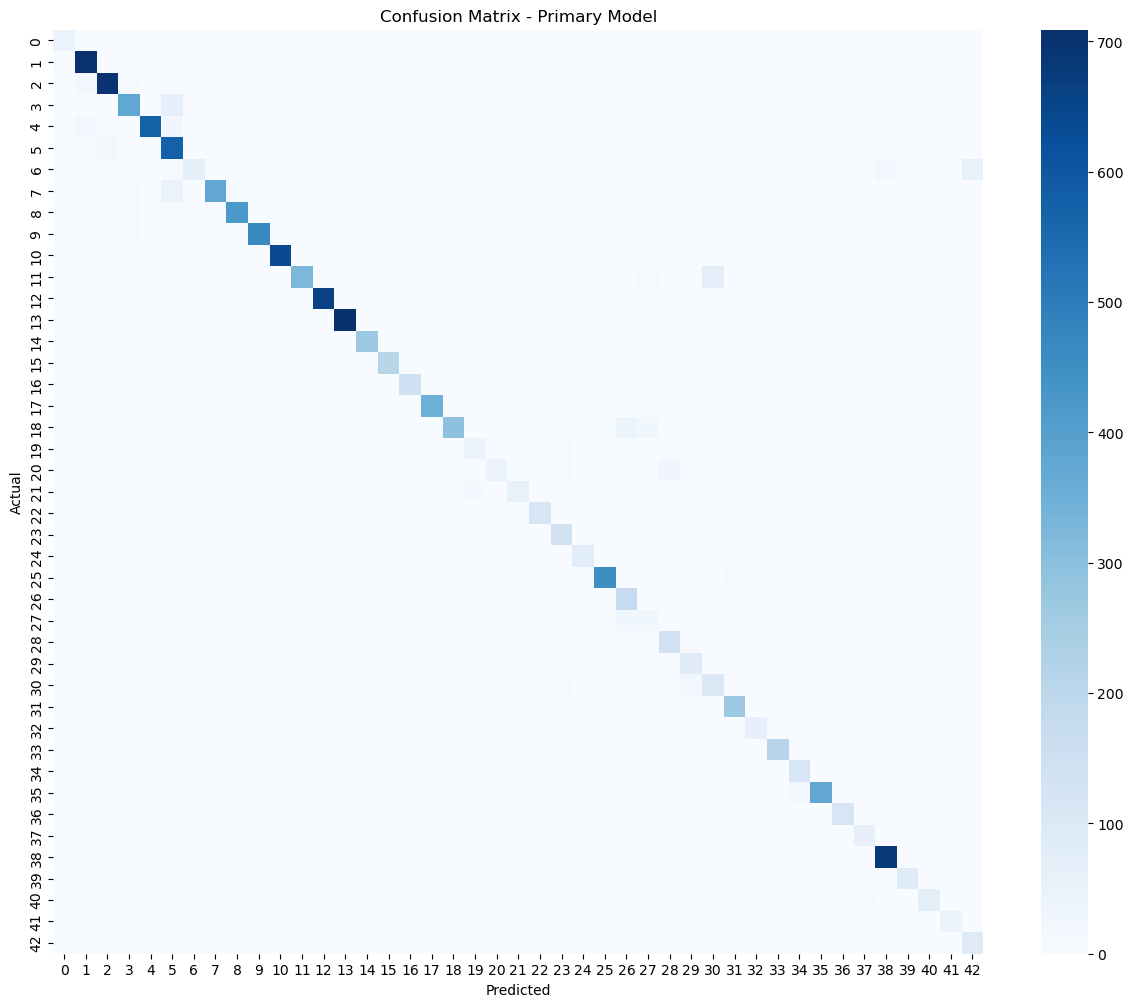

In [16]:
# Function to evaluate and plot
def evaluate_model(model, name):
    print(f"\nEvaluation for {name}:")
    # Get all predictions
    y_true = []
    y_pred = []
    for x, y in test_ds:
        preds = model.predict(x, verbose=0)
        y_pred.extend(tf.argmax(preds, axis=1).numpy())
        y_true.extend(y.numpy())
    
    print(classification_report(y_true, y_pred))
    return y_true, y_pred

# Evaluate Primary Model
y_true, y_pred = evaluate_model(primary_model, "Custom CNN (Primary)")

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix - Primary Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()